In [16]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import scipy.stats as st
import seaborn as sns

In [17]:
df = pd.read_csv(r'C:\Users\sam\Customer_chrun_df2.csv')

In [18]:
df.sample(5)

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
3052,C03053,United Kingdom,29,Male,Silver,2024-05-03,17,755.73,44.45,26,Automotive,Desktop,PayPal,Email Campaign,6,4.3,2,0,1,0
875,C00876,Australia,38,Male,Free,2025-09-08,19,501.88,26.41,52,Electronics,Mobile,Credit Card,Organic Search,4,3.4,2,2,1,0
5961,C05962,Mexico,53,Male,Free,2025-08-21,38,1317.76,34.68,38,Electronics,Desktop,PayPal,Social Media,5,4.6,1,1,1,0
1467,C01468,Netherlands,30,Male,Free,2024-04-02,12,51.57,4.30,79,Books,Desktop,Buy Now Pay Later,Referral,0,3.4,0,2,0,0
7836,C07837,Mexico,32,Female,Free,2024-10-29,17,300.24,17.66,20,Home & Kitchen,Mobile,Credit Card,Social Media,4,4.2,1,1,1,0


## EDA

In [19]:
df.shape

(8000, 20)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               8000 non-null   object 
 1   country                   8000 non-null   object 
 2   age                       8000 non-null   int64  
 3   gender                    8000 non-null   object 
 4   membership_tier           8000 non-null   object 
 5   registration_date         8000 non-null   object 
 6   total_orders              8000 non-null   int64  
 7   total_spend_usd           8000 non-null   float64
 8   avg_order_value_usd       8000 non-null   float64
 9   days_since_last_purchase  8000 non-null   int64  
 10  preferred_category        8000 non-null   object 
 11  preferred_device          8000 non-null   object 
 12  preferred_payment_method  8000 non-null   object 
 13  acquisition_channel       8000 non-null   object 
 14  reviews_

In [21]:
print("NULL VALUES" ,df.isnull().any().sum())

print("NAN VALUES" ,df.isna().any().sum())

NULL VALUES 0
NAN VALUES 0


In [22]:
df.describe()

,age,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,35.616375,18.586875,1558.642350,132.847245,63.96975,3.228750,3.765644,0.849500,4.457125,0.661500,0.205750
std,11.170455,12.910453,2284.094953,474.566919,60.94305,3.942698,0.803986,1.407337,4.854391,0.473229,0.404274
min,18.000000,1.000000,4.890000,0.480000,0.00000,0.000000,1.900000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,8.000000,336.055000,28.520000,22.00000,0.000000,3.298050,0.000000,1.000000,0.000000,0.000000
50%,35.000000,17.000000,845.700000,61.140000,47.00000,2.000000,3.900000,0.000000,3.000000,1.000000,0.000000
75%,43.000000,28.000000,1892.165000,124.120000,76.00000,5.000000,4.400000,1.000000,6.000000,1.000000,0.000000
max,75.000000,79.000000,61282.480000,19449.630000,582.00000,28.000000,5.000000,11.000000,41.000000,1.000000,1.000000


### Distribution of the Data 

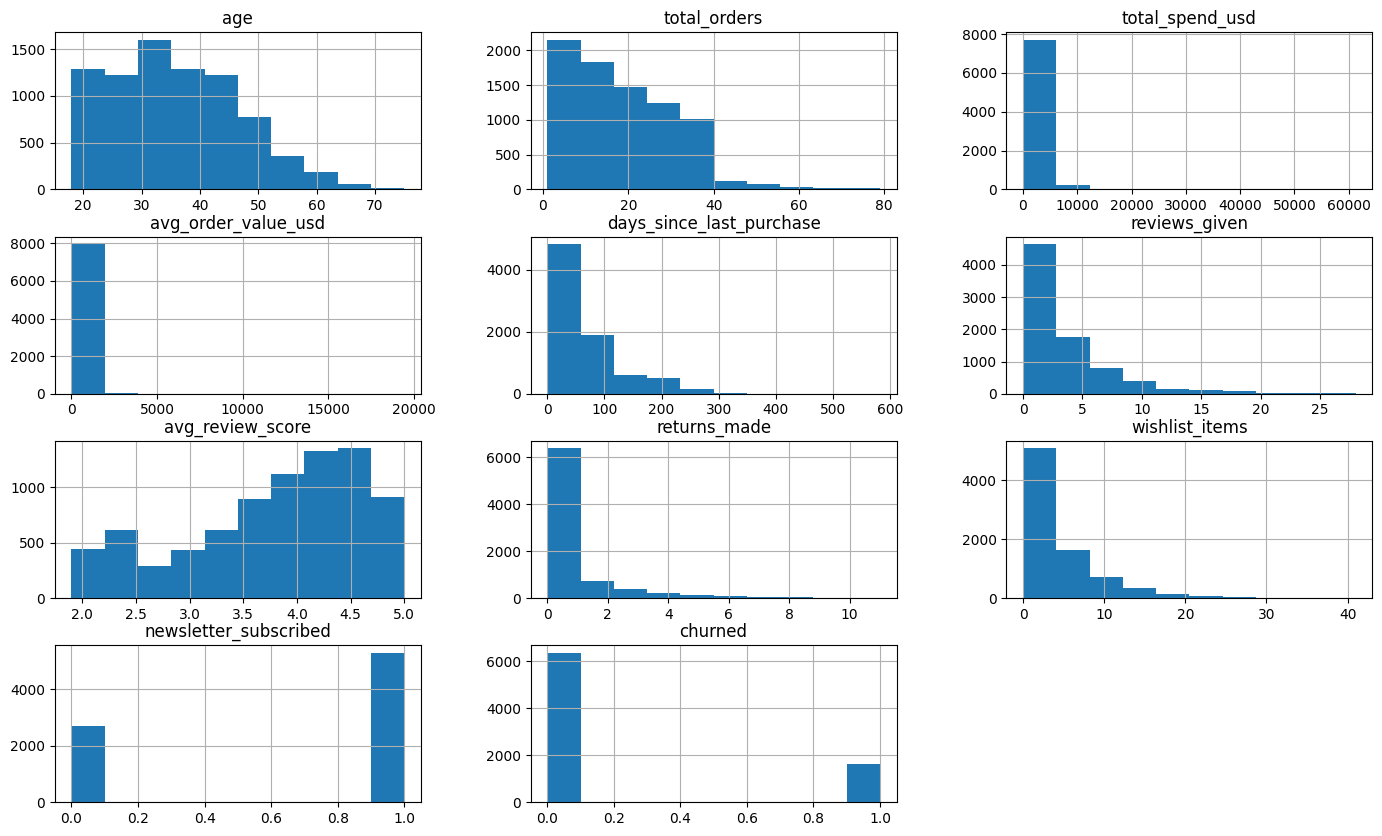

In [23]:
df.hist(figsize=(17,10))
plt.show()

- Age: Most customers are between 20–50 years, with fewer customers in the older age groups

- Purchase behavior: total_orders, total_spend_usd, avg_order_value_usd, days_since_last_purchase, reviews_given, returns_made, and wishlist_items are right-skewed, meaning most customers have relatively low values while a small number have very high values.

- Review score: Customers generally give high ratings, with most scores concentrated between 3.5 and 5.0, especially around 4–4.5.

- Churn: The dataset is imbalanced, with considerably more non-churned customers than churned customers, so churn-related analysis should account for this imbalance.

## BUSINESS UNDERSTADING

### The company wants to reduce avoidable customer loss and use its retention budget more efficiently by identifying customers who are likely to churn and determining which of those customers are valuable enough to prioritize.

![image.png](attachment:image.png)

### Problem 1 — Understand the customers

The company wants to know:

Who are our customers and how do they behave?

Text(0.5, 1.0, 'Churn vs Not Chrun ')

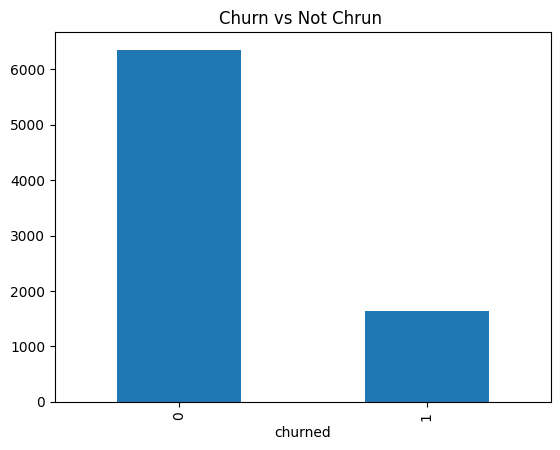

In [24]:
df['churned'].value_counts().plot(kind='bar')
plt.title("Churn vs Not Chrun ")

## The Data is IMBALANCED 

In [25]:
df.sample()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
5288,C05289,Mexico,58,Male,Free,2023-03-22,8,737.87,92.23,172,Electronics,Desktop,Bank Transfer,Direct,2,2.405365,1,2,1,1


<Axes: ylabel='count'>

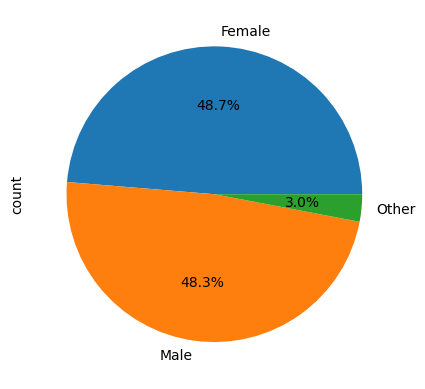

In [26]:
df['gender'].value_counts().plot(
    kind='pie',
    labels=df['gender'].value_counts().index,
    autopct='%1.1f%%'
)

<Axes: xlabel='country', ylabel='total_spend_usd'>

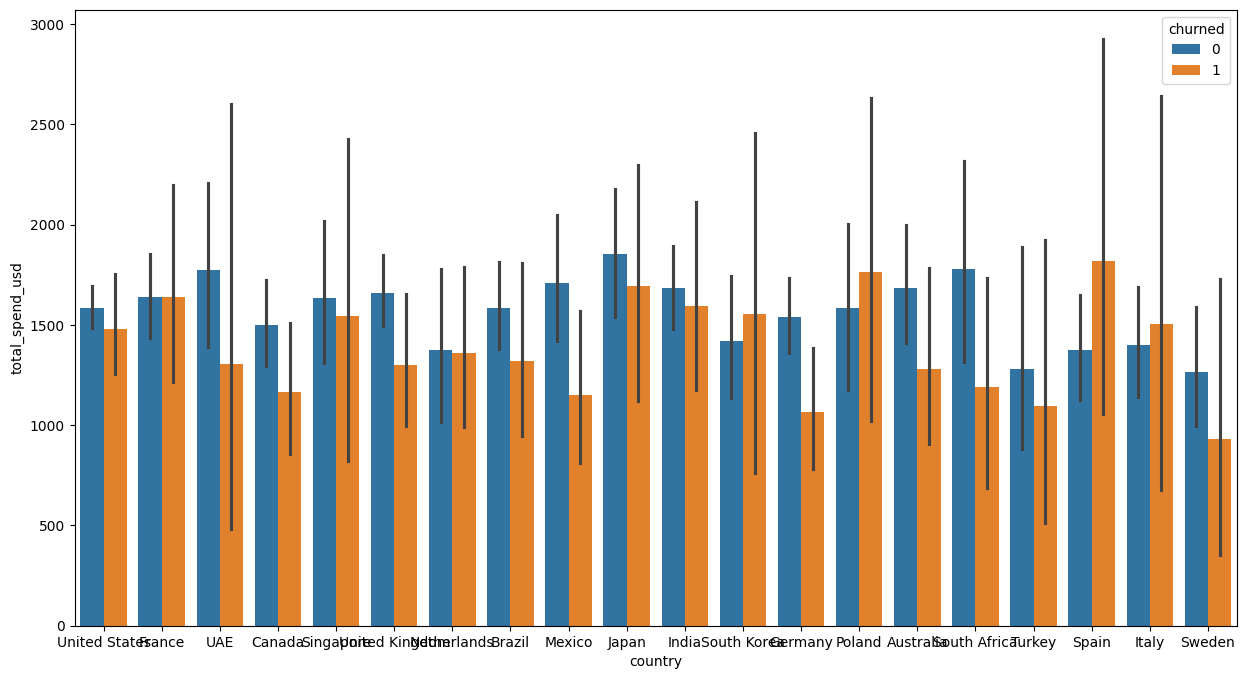

In [27]:
plt.figure(figsize=(15,8))
sns.barplot(
    data=df,
    x='country',
    y='total_spend_usd',
    hue='churned'

)

In [28]:
df.sample()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
4617,C04618,France,32,Female,Free,2024-02-18,1,689.63,689.63,94,Beauty & Personal Care,Desktop,Cryptocurrency,Social Media,2,3.7,0,10,1,1


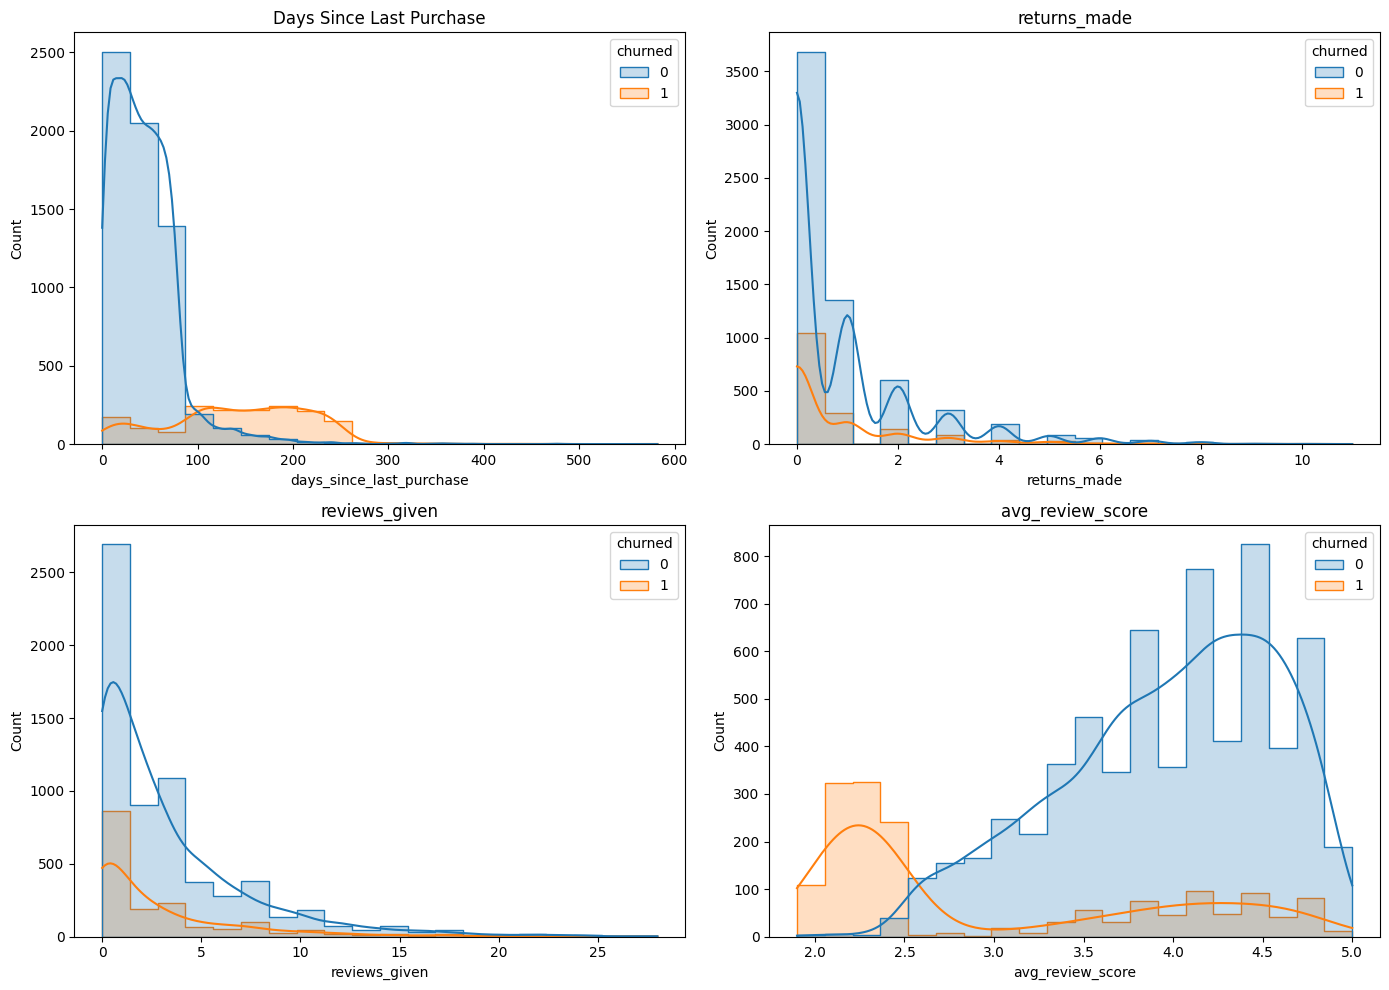

In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Days since last purchase
sns.histplot(
    data=df,
    x='days_since_last_purchase',
    hue='churned',
    bins=20,
    kde=True,
    element='step',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Days Since Last Purchase')

# 2. Total orders
sns.histplot(
    data=df,
    x='returns_made',
    hue='churned',
    bins=20,
    kde=True,
    element='step',
    ax=axes[0, 1]
)
axes[0, 1].set_title('returns_made')

# 3. Total spend
sns.histplot(
    data=df,
    x='reviews_given',
    hue='churned',
    bins=20,
    kde=True,
    element='step',
    ax=axes[1, 0]
)
axes[1, 0].set_title('reviews_given')

# 4. Average review score
sns.histplot(
    data=df,
    x='avg_review_score',
    hue='churned',
    bins=20,
    kde=True,
    element='step',
    ax=axes[1, 1]
)
axes[1, 1].set_title('avg_review_score')

plt.tight_layout()
plt.show()

#### Days since last purchase: Churned customers tend to have more days since their last purchase, suggesting that inactive customers are more likely to churn.

#### Returns made: Most customers make few or no returns. Churned customers also show a similar pattern, so returns do not appear to be a very strong churn indicator.

#### Reviews given: Most customers give very few reviews. Churned customers are also concentrated at low review counts, so review frequency alone may not strongly distinguish churn.

#### Average review score: Churned customers tend to have lower review scores, especially around 2–2.5, while non-churned customers are concentrated around 4–4.5. This looks like a stronger churn-related factor.

In [15]:
df.sample()

,customer_id,country,age,gender,membership_tier,registration_date,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
3132,C03133,United States,40,Male,Silver,2025-07-06,26,32.86,1.26,60,Automotive,Desktop,Buy Now Pay Later,Organic Search,0,4.4,0,1,1,0


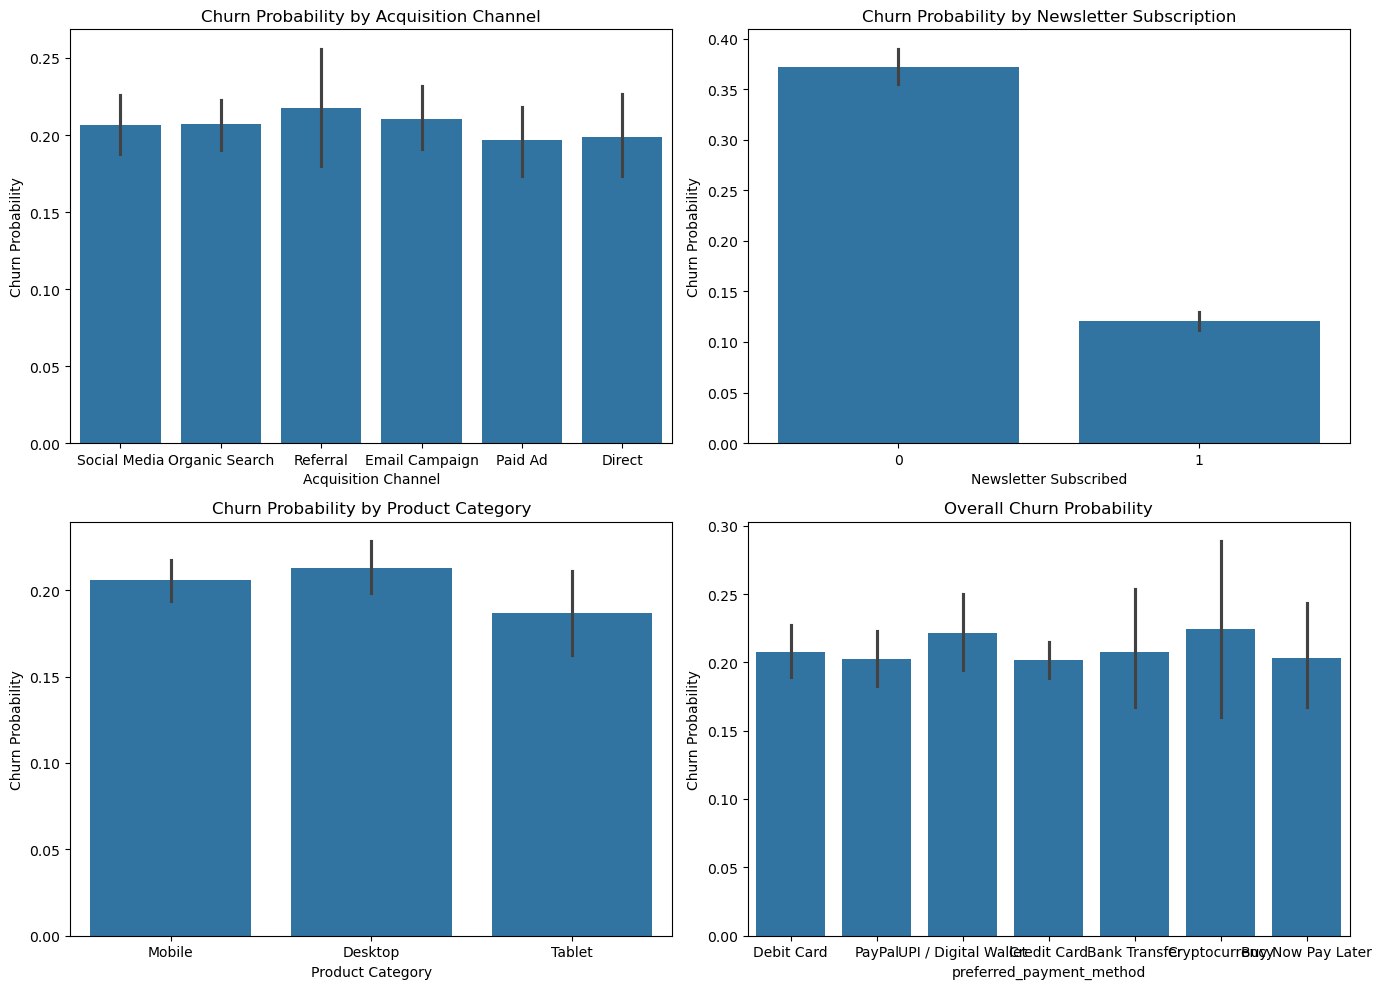

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Acquisition channel vs churn probability
sns.barplot(
    data=df,
    x='acquisition_channel',
    y='churned',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Churn Probability by Acquisition Channel')
axes[0, 0].set_ylabel('Churn Probability')
axes[0, 0].set_xlabel('Acquisition Channel')

# 2. Newsletter subscription vs churn probability
sns.barplot(
    data=df,
    x='newsletter_subscribed',
    y='churned',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Churn Probability by Newsletter Subscription')
axes[0, 1].set_ylabel('Churn Probability')
axes[0, 1].set_xlabel('Newsletter Subscribed')

# 3. Product category vs churn probability
sns.barplot(
    data=df,
    x='preferred_device',
    y='churned',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Churn Probability by Product Category')
axes[1, 0].set_ylabel('Churn Probability')
axes[1, 0].set_xlabel('Product Category')

# 4. Overall churn rate
sns.barplot(
    data=df,
    x='preferred_payment_method',
    y='churned',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Overall Churn Probability')
axes[1, 1].set_ylabel('Churn Probability')

plt.tight_layout()
plt.show()

#### Acquisition channel: Churn probability is fairly similar across channels (~18–22%). Direct has the highest churn (~22%), while Referral is lowest (~18%). So, acquisition channel does not appear to be a major churn driver.

#### Newsletter: This is the strongest difference. Customers who did not subscribe have about 37% churn probability, compared with only 13% for subscribers.
- Newsletter subscribers are much less likely to churn.

#### Device/category: Mobile and Desktop have almost the same churn probability (~21%), while Tablet is slightly lower (~18%).
- Device type has only a small relationship with churn.

#### Payment method: Churn probabilities are fairly similar across payment methods, mostly around 19–22%.
- Payment method doesn't appear to strongly influence churn.

### Strongest business insight

- Newsletter subscription stands out as the most important factor among these variables: non-subscribers have roughly 3× the churn probability of subscribers (37% vs 13%).

### RFM Analysis

- R — Recency: How recently did they purchase?
- F — Frequency: How often did they purchase?
- M — Monetary: How much did they spend?

In [17]:
rfm = df[
    [
        'customer_id',
        'days_since_last_purchase',
        'total_orders',
        'total_spend_usd'
    ]
].copy()


rfm.head()

,customer_id,days_since_last_purchase,total_orders,total_spend_usd
0,C00001,49,4,286.63
1,C00002,107,11,1245.18
2,C00003,0,24,195.37
3,C00004,6,6,99.45
4,C00005,48,13,2593.21


In [18]:
rfm = rfm.rename(columns={'days_since_last_purchase':'days_since_last_purchase_R',
                    'total_orders':'total_orders_F','total_spend_usd':'total_spend_usd_M'})

In [19]:
rfm['R_score'] = pd.qcut(
    rfm['days_since_last_purchase_R'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

In [20]:
rfm['F_score'] = pd.qcut(
    rfm['total_orders_F'],
    q=5,
    labels=[1, 2, 3, 4, 5],
    duplicates='drop'
)

In [21]:
rfm['M_score'] = pd.qcut(
    rfm['total_spend_usd_M'],
    q=5,
    labels=[5, 4, 3, 2, 1],
    duplicates='drop'
)

In [22]:
rfm

,customer_id,days_since_last_purchase_R,total_orders_F,total_spend_usd_M,R_score,F_score,M_score
0,C00001,49,4,286.63,3,1,4
1,C00002,107,11,1245.18,5,2,2
2,C00003,0,24,195.37,1,4,5
3,C00004,6,6,99.45,1,1,5
4,C00005,48,13,2593.21,3,2,1
...,...,...,...,...,...,...,...
7995,C07996,132,7,1953.76,5,1,2
7996,C07997,68,31,6772.20,4,4,1
7997,C07998,41,46,2430.09,3,5,1
7998,C07999,182,9,5552.56,5,2,1


In [23]:
rfm['M_score'] = rfm['M_score'].astype(int)
rfm['F_score'] = rfm['F_score'].astype(int)
rfm['R_score'] = rfm['R_score'].astype(int)

In [24]:
print(rfm['M_score'].dtype)

int64


In [25]:
# Absolute top-tier champions
rfm[(rfm['R_score'] > 4) & (rfm['F_score'] > 4) & (rfm['M_score'] >= 4)].head()


,customer_id,days_since_last_purchase_R,total_orders_F,total_spend_usd_M,R_score,F_score,M_score
392,C00393,244,32,413.48,5,5,4
580,C00581,143,38,161.75,5,5,5
1099,C01100,137,37,271.55,5,5,4
1312,C01313,114,38,143.69,5,5,5
1762,C01763,156,38,564.30,5,5,4


## MODEL BUILDING PROCESS AND STAGES 

## import the Liabraries

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import power_transform , FunctionTransformer 
from sklearn.feature_selection import chi2 , f_classif ,mutual_info_classif ,RFE

In [31]:
model_df = df.copy()

model_df = model_df.drop(
    columns=['customer_id', 'registration_date']
)

model_df.head()

,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,United States,40,Male,Free,4,286.63,71.66,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.500000,0,12,1,0
1,United States,20,Female,Free,11,1245.18,113.20,107,Toys & Games,Mobile,Debit Card,Organic Search,2,2.600000,1,1,0,1
2,United States,43,Female,Gold,24,195.37,8.14,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.800000,0,0,1,0
3,United States,41,Male,Free,6,99.45,16.58,6,Electronics,Desktop,PayPal,Organic Search,2,4.200000,0,8,1,0
4,France,37,Other,Platinum,13,2593.21,199.48,48,Clothing & Apparel,Tablet,Debit Card,Social Media,9,2.990747,4,5,1,0


In [32]:
categorical_cols = [
    'country',
    'gender',
    'membership_tier',
    'preferred_category',
    'preferred_device',
    'preferred_payment_method',
    'acquisition_channel',
    'newsletter_subscribed'
]

In [33]:
from scipy.stats import chi2_contingency
import pandas as pd

chi_results = []

for col in categorical_cols:
    table = pd.crosstab(model_df[col], model_df['churned'])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_results.append({
        'feature': col,
        'chi2': chi2,
        'p_value': p_value
    })

chi_results = pd.DataFrame(chi_results).sort_values('p_value',ascending=True)

chi_results

,feature,chi2,p_value
7,newsletter_subscribed,692.762315,1.120980e-152
2,membership_tier,6.732983,8.091345e-02
0,country,23.877964,2.008752e-01
4,preferred_device,2.982816,2.250555e-01
3,preferred_category,9.981152,6.954749e-01
1,gender,0.419996,8.105860e-01
6,acquisition_channel,1.513644,9.114899e-01
5,preferred_payment_method,2.054222,9.146449e-01


In [34]:
pd.crosstab(model_df['preferred_device'],model_df['churned'])

churned,0,1
preferred_device,,
Desktop,2093,566
Mobile,3456,895
Tablet,805,185


## Outliers Removals

In [35]:
model_df.sample(5)

,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
2911,United Kingdom,31,Female,Free,1,26.78,26.78,6,Electronics,Mobile,Credit Card,Organic Search,0,4.500000,0,0,1,0
1131,United States,48,Male,Free,8,1772.61,221.58,90,Toys & Games,Mobile,PayPal,Organic Search,1,2.160468,2,2,0,1
5576,Spain,28,Female,Silver,21,1817.00,86.52,100,Electronics,Tablet,Credit Card,Email Campaign,5,2.900000,0,14,1,0
4029,United Kingdom,39,Male,Free,16,27.64,1.73,63,Clothing & Apparel,Desktop,UPI / Digital Wallet,Organic Search,0,4.000000,0,8,1,0
1731,Mexico,19,Female,Free,34,1415.27,41.63,62,Home & Kitchen,Mobile,Credit Card,Organic Search,12,4.900000,0,7,1,0


### Avg_order_value_usd

<Axes: >

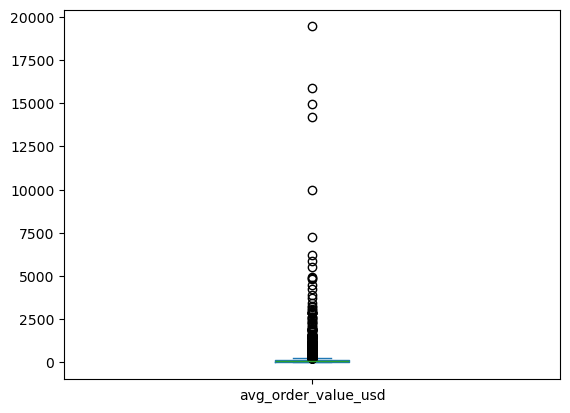

In [32]:
model_df['avg_order_value_usd'].plot(kind='box')

<Axes: ylabel='Frequency'>

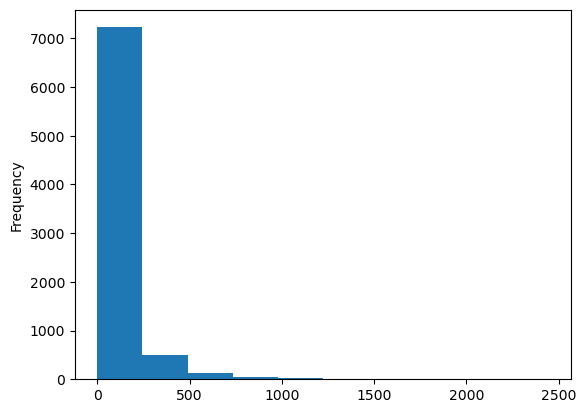

In [33]:
model_df[model_df['avg_order_value_usd']<=2500]['avg_order_value_usd'].plot(kind='hist')

## Business scenario

##### Assume the company has a normal individual-purchase limit:

### A single customer order should not have an average order value above $5,000. High-value purchases above this limit are expected to involve multiple orders rather than one unusually expensive order.

In [34]:
suspect = (
    (df['avg_order_value_usd'] > 5000) &
    (df['total_orders'] == 1)
)

In [35]:
def get_iqr(column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    print("IQR:", IQR)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    
    return IQR, lower_bound, upper_bound

## remove those records

In [36]:
df = df[~suspect].copy()

In [37]:
df.shape

(7992, 20)

In [38]:
def outlier_plot(column):
    
    fig , ax = plt.subplots(ncols=2 ,figsize=(12, 4))
    
    ax[0].hist(column, bins=30)
    ax[0].set_title('Histogram')
    ax[0].set_xlabel(column.name)
    ax[0].set_ylabel('Frequency')

    # Box plot
    ax[1].boxplot(column)
    ax[1].set_title('Box Plot')
    ax[1].set_ylabel(column.name)

    plt.tight_layout()
    plt.show()
    
    

## Total_orders

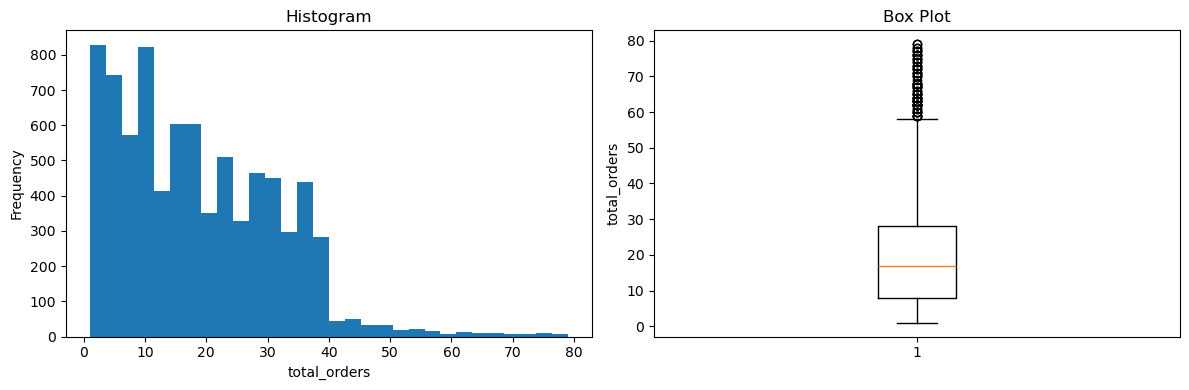

In [39]:
outlier_plot(df['total_orders'])

In [40]:
get_iqr('total_orders')

IQR: 20.0
Lower bound: -22.0
Upper bound: 58.0


(np.float64(20.0), np.float64(-22.0), np.float64(58.0))

## total_spend_usd

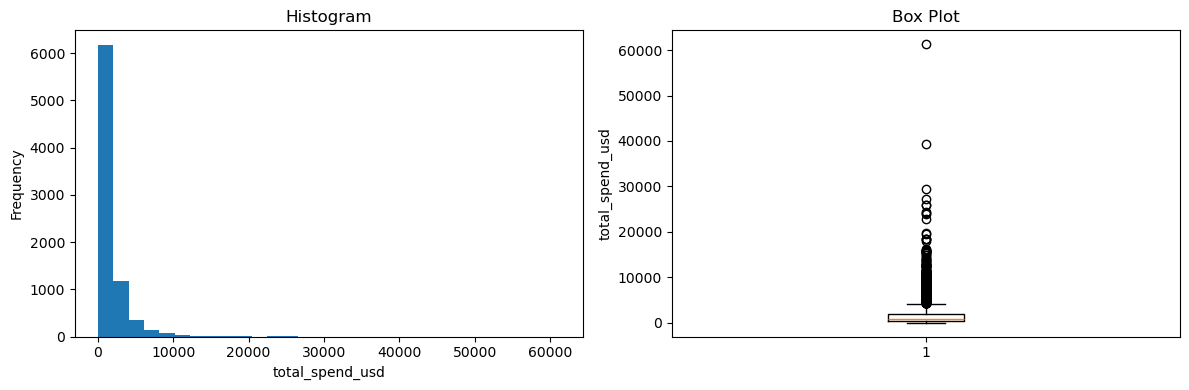

In [41]:
outlier_plot(df['total_spend_usd'])

In [42]:
get_iqr('total_spend_usd')

IQR: 1552.8374999999999
Lower bound: -1993.7337499999999
Upper bound: 4217.61625


(np.float64(1552.8374999999999),
 np.float64(-1993.7337499999999),
 np.float64(4217.61625))

### days_since_last_purchase

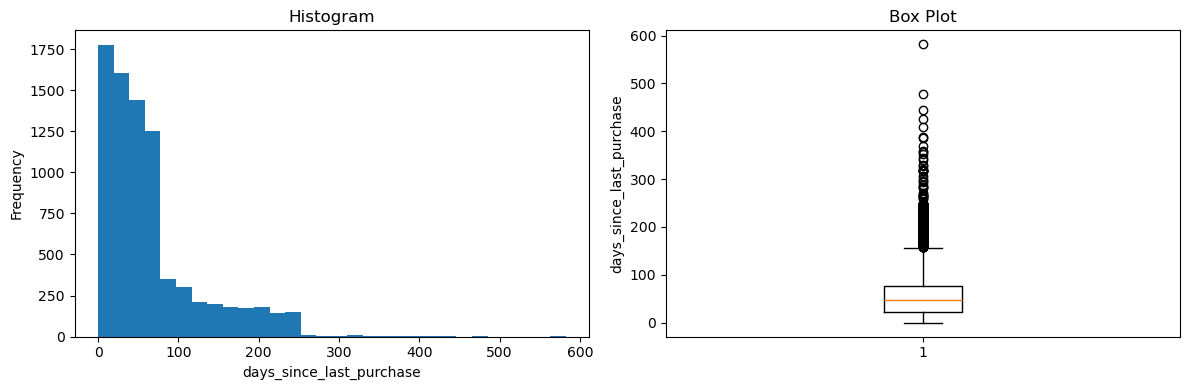

In [43]:
outlier_plot(df['days_since_last_purchase'])

In [44]:
get_iqr('days_since_last_purchase')

IQR: 54.0
Lower bound: -59.0
Upper bound: 157.0


(np.float64(54.0), np.float64(-59.0), np.float64(157.0))

### reviews_given

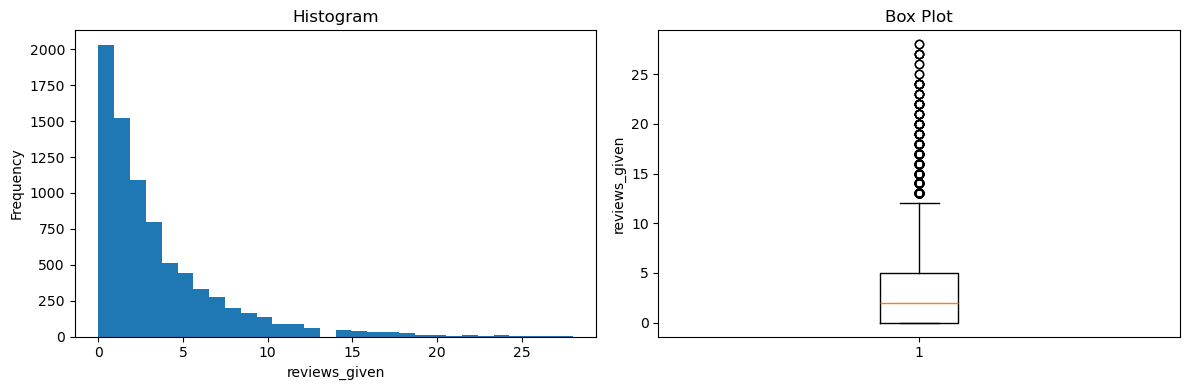

In [45]:
outlier_plot(df['reviews_given'])

In [46]:
get_iqr('reviews_given')

IQR: 5.0
Lower bound: -7.5
Upper bound: 12.5


(np.float64(5.0), np.float64(-7.5), np.float64(12.5))

## avg_review_score

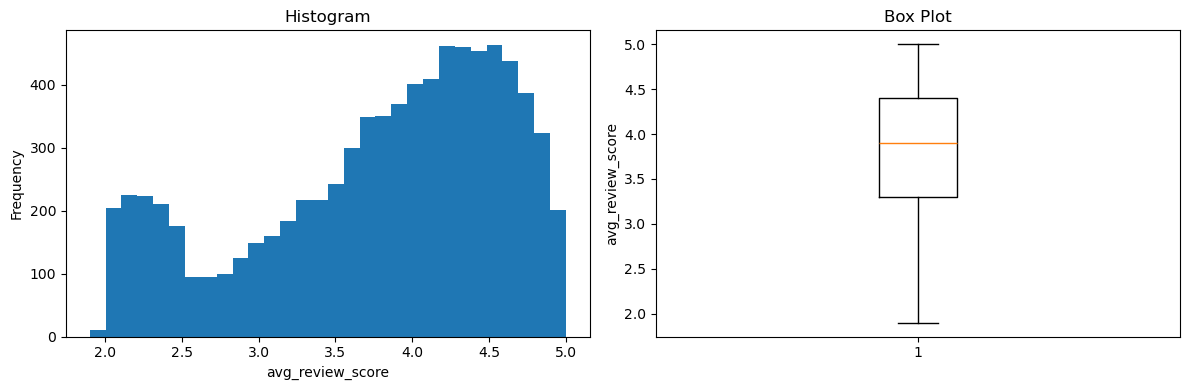

In [47]:
outlier_plot(df['avg_review_score'])

In [48]:
get_iqr('avg_review_score')

IQR: 1.1000973858915035
Lower bound: 1.6497565352712416
Upper bound: 6.050146078837256


(np.float64(1.1000973858915035),
 np.float64(1.6497565352712416),
 np.float64(6.050146078837256))

## Outlier Treatment

- We used the **IQR method** to identify potential outliers because the numerical variables were not normally distributed.
- Outliers were investigated using **business logic** rather than being removed automatically.
- Only records considered **invalid or suspicious based on the business rule** were removed.
- Genuine extreme values were **retained** because they can represent real customer behavior.
- General **trimming and capping were not applied**.
- Highly right-skewed variables can be considered for **log transformation** during preprocessing.

### Treatment of Each Numerical Column

| Column | Observation | Treatment |
|---|---|---|
| `age` | High ages were statistical outliers but were realistic | **Kept** |
| `total_orders` | High order counts were possible for active customers | **Kept** |
| `total_spend_usd` | High spending values represented genuine high-value customers | **Kept** |
| `avg_order_value_usd` | Very high values with only 1 order were considered suspicious | **Removed based on business rule** |
| `days_since_last_purchase` | High values were genuine and relevant to churn | **Kept** |
| `wishlist_items` | High values represented possible customer behavior | **Kept** |

### Overall Conclusion

> **IQR was used to detect potential outliers, while business logic was used to decide their treatment. Only suspicious/invalid records were removed, while genuine extreme values were retained.**

## Feature Enginerring

In [8]:
model_df = df.drop(
    columns=[ 'registration_date'].copy()
)

In [9]:
model_df

,customer_id,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
0,C00001,United States,40,Male,Free,4,286.63,71.66,49,Food & Grocery,Mobile,Debit Card,Social Media,1,4.500000,0,12,1,0
1,C00002,United States,20,Female,Free,11,1245.18,113.20,107,Toys & Games,Mobile,Debit Card,Organic Search,2,2.600000,1,1,0,1
2,C00003,United States,43,Female,Gold,24,195.37,8.14,0,Home & Kitchen,Mobile,PayPal,Referral,0,4.800000,0,0,1,0
3,C00004,United States,41,Male,Free,6,99.45,16.58,6,Electronics,Desktop,PayPal,Organic Search,2,4.200000,0,8,1,0
4,C00005,France,37,Other,Platinum,13,2593.21,199.48,48,Clothing & Apparel,Tablet,Debit Card,Social Media,9,2.990747,4,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,C07996,United States,36,Male,Gold,7,1953.76,279.11,132,Jewelry & Accessories,Tablet,Debit Card,Social Media,1,2.238284,1,14,1,1
7996,C07997,India,42,Male,Free,31,6772.20,218.46,68,Electronics,Mobile,Credit Card,Paid Ad,12,3.356411,4,1,0,0
7997,C07998,India,34,Male,Platinum,46,2430.09,52.83,41,Home & Kitchen,Desktop,Cryptocurrency,Organic Search,9,4.200000,6,0,1,0
7998,C07999,Japan,44,Female,Free,9,5552.56,616.95,182,Food & Grocery,Mobile,Credit Card,Paid Ad,10,4.100000,1,2,0,1


In [36]:
X = model_df.drop('churned', axis=1)
y = model_df['churned']

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder ,OrdinalEncoder


In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'total_orders'}>,
        <Axes: title={'center': 'total_spend_usd'}>],
       [<Axes: title={'center': 'avg_order_value_usd'}>,
        <Axes: title={'center': 'days_since_last_purchase'}>,
        <Axes: title={'center': 'reviews_given'}>],
       [<Axes: title={'center': 'avg_review_score'}>,
        <Axes: title={'center': 'returns_made'}>,
        <Axes: title={'center': 'wishlist_items'}>],
       [<Axes: title={'center': 'newsletter_subscribed'}>,
        <Axes: title={'center': 'churned'}>, <Axes: >]], dtype=object)

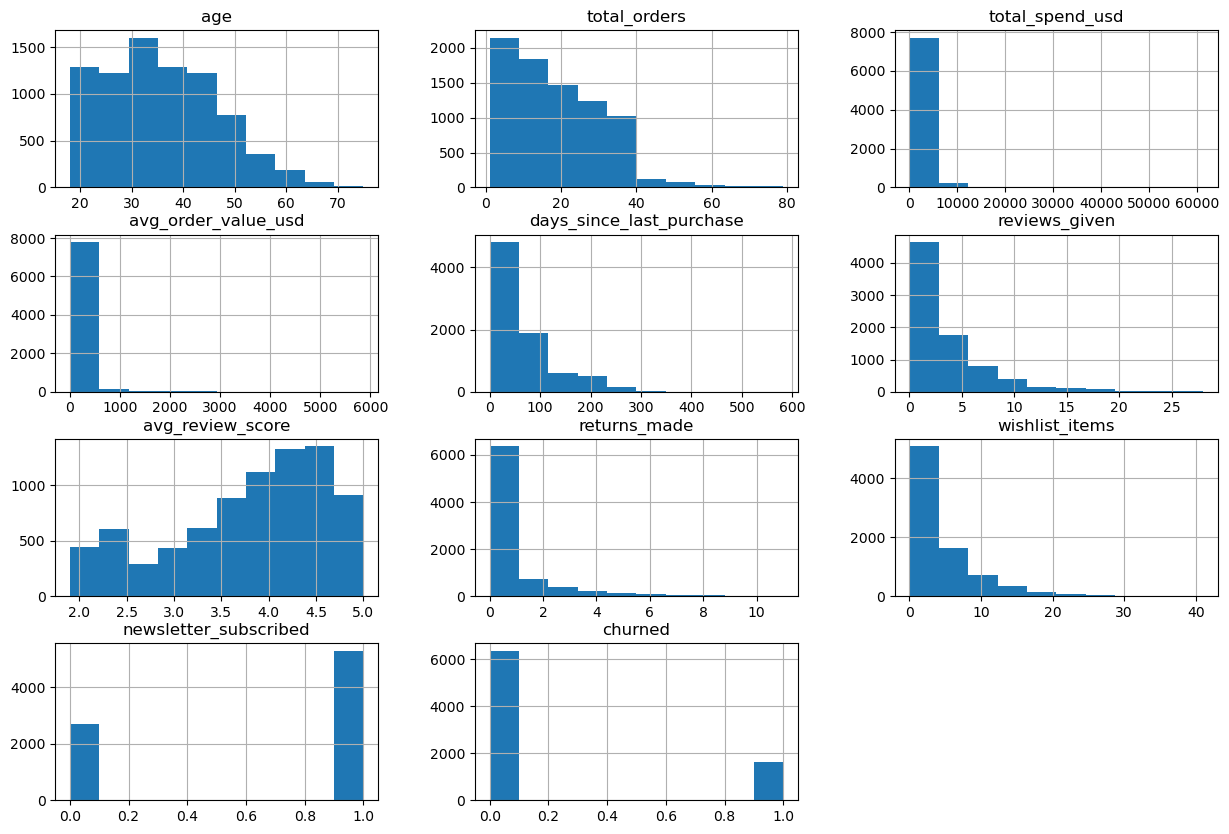

In [54]:
model_df.hist(figsize=(15,10))

### Log columns

In [55]:
model_df.sample(1)

,customer_id,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed,churned
2731,C02732,Germany,30,Female,Free,37,452.58,12.23,49,Clothing & Apparel,Tablet,Cryptocurrency,Email Campaign,0,2.6,0,1,0,0


In [39]:
log_cols = [
    'total_orders',
    'total_spend_usd',
    'avg_order_value_usd',
    'days_since_last_purchase',
    'reviews_given',
    'returns_made',
    'wishlist_items'
]

onehot_cols = [
    'country',
    'gender',
    'preferred_category',
    'preferred_device',
    'preferred_payment_method',
    'acquisition_channel'
]

ordinal_cols = ['membership_tier']

numeric_cols = [
    'age',
    'avg_review_score',
    'newsletter_subscribed'
]

### Transforming the columns

In [40]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    MinMaxScaler
)
import numpy as np

In [41]:
t1 = Pipeline([
    ('log_1p' , FunctionTransformer(func=np.log1p,feature_names_out='one-to-one'))
])

t2 = Pipeline([
    ('one_hot_encoding',OneHotEncoder(handle_unknown='ignore',sparse_output=False) )
])


t3 = Pipeline([
    ('ordinal_encoding', OrdinalEncoder(
        categories=[
            ['Free', 'Silver', 'Gold', 'Platinum']
        ]
    ))
])




In [42]:
preprocessor = ColumnTransformer([
    
    # Log transformation
    ('log', t1, log_cols),
    
    # One-hot encoding
    ('onehot', t2, onehot_cols),
    
    # Ordinal encoding
    ('ordinal', t3, ordinal_cols),
    
    ('numeric', 'passthrough', numeric_cols)

])

In [43]:
preprocessor.fit_transform(X_train)

array([[ 3.04452244,  8.4452739 ,  5.45361025, ..., 58.        ,
         4.1       ,  0.        ],
       [ 2.30258509,  7.16451154,  4.9734871 , ..., 28.        ,
         4.        ,  1.        ],
       [ 0.69314718,  7.96714845,  7.96714845, ..., 41.        ,
         4.7       ,  1.        ],
       ...,
       [ 2.89037176,  7.22545964,  4.40378813, ..., 32.        ,
         3.8       ,  1.        ],
       [ 3.25809654,  7.00869504,  3.8113183 , ..., 39.        ,
         4.4       ,  1.        ],
       [ 2.19722458,  5.78425586,  3.72617524, ..., 26.        ,
         4.4       ,  1.        ]], shape=(6400, 64))

In [44]:
feature_names = preprocessor.get_feature_names_out()

print(feature_names)
print("Total features:", len(feature_names))

['log__total_orders' 'log__total_spend_usd' 'log__avg_order_value_usd'
 'log__days_since_last_purchase' 'log__reviews_given' 'log__returns_made'
 'log__wishlist_items' 'onehot__country_Australia'
 'onehot__country_Brazil' 'onehot__country_Canada'
 'onehot__country_France' 'onehot__country_Germany'
 'onehot__country_India' 'onehot__country_Italy' 'onehot__country_Japan'
 'onehot__country_Mexico' 'onehot__country_Netherlands'
 'onehot__country_Poland' 'onehot__country_Singapore'
 'onehot__country_South Africa' 'onehot__country_South Korea'
 'onehot__country_Spain' 'onehot__country_Sweden' 'onehot__country_Turkey'
 'onehot__country_UAE' 'onehot__country_United Kingdom'
 'onehot__country_United States' 'onehot__gender_Female'
 'onehot__gender_Male' 'onehot__gender_Other'
 'onehot__preferred_category_Automotive'
 'onehot__preferred_category_Beauty & Personal Care'
 'onehot__preferred_category_Books'
 'onehot__preferred_category_Clothing & Apparel'
 'onehot__preferred_category_Electronics'
 

In [62]:
X_train_transformed = pd.DataFrame(preprocessor.fit_transform(X_train),columns=feature_names)

In [63]:
X_test_transformed = pd.DataFrame(preprocessor.transform(X_test),columns=feature_names)

In [64]:
X_test_transformed

,log__total_orders,log__total_spend_usd,log__avg_order_value_usd,log__days_since_last_purchase,log__reviews_given,log__returns_made,log__wishlist_items,onehot__country_Australia,onehot__country_Brazil,onehot__country_Canada,...,onehot__acquisition_channel_Direct,onehot__acquisition_channel_Email Campaign,onehot__acquisition_channel_Organic Search,onehot__acquisition_channel_Paid Ad,onehot__acquisition_channel_Referral,onehot__acquisition_channel_Social Media,ordinal__membership_tier,numeric__age,numeric__avg_review_score,numeric__newsletter_subscribed
0,3.218876,6.162156,3.031582,4.382027,0.693147,0.000000,2.484907,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,2.0,57.0,3.100000,1.0
1,1.386294,8.838961,7.740638,5.446737,2.397895,0.693147,0.000000,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,2.0,48.0,3.000000,1.0
2,1.386294,5.721852,4.629765,5.501258,0.000000,0.000000,1.386294,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,43.0,4.600000,0.0
3,3.044522,8.380168,5.388798,3.761200,1.098612,0.693147,1.791759,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,55.0,3.600000,0.0
4,2.197225,6.487638,4.418841,4.143135,0.693147,0.000000,1.386294,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,29.0,4.500000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,2.197225,6.314689,4.247781,5.356586,0.000000,0.000000,0.000000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,38.0,2.164689,0.0
1595,2.197225,7.049177,4.975768,3.044522,2.079442,1.098612,1.945910,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,36.0,4.400000,1.0
1596,2.197225,7.178256,5.104126,4.025352,1.098612,0.000000,2.639057,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,50.0,4.300000,1.0
1597,3.465736,5.389209,2.083185,3.912023,0.000000,0.000000,1.386294,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,62.0,4.100000,1.0


In [65]:
from sklearn.linear_model import LogisticRegression

## BaseLine Model Logistic Regression without Feature Selection

In [66]:
lr1 = LogisticRegression(max_iter=500,n_jobs=-1)

In [67]:
lr1.fit(X_train_transformed,y_train)

LogisticRegression(max_iter=500, n_jobs=-1)

In [68]:
y_pred = lr1.predict(X_test_transformed)

In [69]:
lr1.score(X_train_transformed,y_train)

0.9296105114969498

In [70]:
from sklearn.metrics import classification_report

In [71]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1306
           1       0.76      0.85      0.80       293

    accuracy                           0.92      1599
   macro avg       0.86      0.89      0.88      1599
weighted avg       0.93      0.92      0.92      1599



In [72]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    lr1,
    X_train_transformed,
    y_train,
    cv=cv,
    scoring='f1'
)

print(scores)
print("Mean F1:", scores.mean())
print("Std F1:", scores.std())


[0.78600823 0.79918033 0.80561122 0.81012658 0.79508197]
Mean F1: 0.7992016660516026
Std F1: 0.008384215222237255


In [73]:
print("var", scores.var())

var 7.029506489279492e-05


In [74]:
X_train_transformed.iloc[:,3]

0       3.688879
1       4.043051
2       4.234107
3       5.278115
4       2.079442
          ...   
6388    3.583519
6389    4.007333
6390    4.356709
6391    1.386294
6392    3.713572
Name: log__days_since_last_purchase, Length: 6393, dtype: float64

## Baseline Model – Logistic Regression

- **Model:** Logistic Regression
- **Feature Selection:** Not performed
- **Features:** All transformed features
- **Churn Precision:** 0.76
- **Churn Recall:** 0.85
- **Churn F1-Score:** 0.80
- **Accuracy:** 0.92.96

### Cross-Validation Results

- **Mean F1-Score:** 0.79
- **Standard Deviation:** 0.0083
- **Variance:** 0.000007

### Conclusion

The baseline model provides a starting point for comparison. It achieves a **CV F1-score of 0.726** and **churn recall of 0.83**. Further improvements will be evaluated using **feature selection, imbalance handling, and different machine learning algorithms**.

In [75]:
from sklearn.metrics import (
    classification_report)

class ModelBuilding :
    
    def __init__(self , model , X_train , y_train , X_test ,y_test):
        
        self.model = model 
        self.X_train = X_train
        self.X_test = X_test
        self.y_train = y_train
        self.y_test = y_test
        
    def MOdel_building(self):
        
        self.model.fit(self.X_train ,self.y_train)
        
        return self.model
    
    
    def Classifaction_report(self):
        
        try:
            model = self.MOdel_building()
            
            predictions = model.predict(self.X_test)
            
            return print(classification_report(predictions , self.y_test))
        except ImportError as i:
            raise i
            
        
        

In [76]:
from imblearn.ensemble import BalancedRandomForestClassifier

model = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

brf_model = ModelBuilding(
    model=model,
    X_train=X_train_transformed,
    y_train=y_train,
    X_test=X_test_transformed,
    y_test = y_test
)


brf_model.Classifaction_report()


              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1260
           1       0.93      0.90      0.92       339

    accuracy                           0.97      1599
   macro avg       0.95      0.94      0.95      1599
weighted avg       0.97      0.97      0.97      1599



## Feature Selection 

#### Feature selection using the Lasso l2 

In [77]:
from sklearn.linear_model import Lasso

In [78]:
from sklearn.linear_model import LogisticRegression

l1 = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1.0,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

l1.fit(X_train_transformed, y_train)

X_train_l1 = X_train_transformed.loc[:, l1_mask]
X_test_l1 = X_test_transformed.loc[:, l1_mask]

print("Original:", X_train_transformed.shape[1])
print("L1 selected:", X_train_l1.shape[1])

NameError: name 'l1_mask' is not defined

In [ ]:
X_train_transformed.loc[:,~l1_mask]

## Chi-square feature selection

#### Use Chi-square only on your one-hot categorical features.

In [79]:
import numpy as np
import pandas as pd
from sklearn.feature_selection import chi2

feature_names = np.array(
    preprocessor.get_feature_names_out()
)

# Find one-hot encoded feature positions
onehot_idx = [
    i for i, f in enumerate(feature_names)
    if f.startswith('onehot__')
]

X_train_cat = X_train_transformed.iloc[:, onehot_idx]

chi_scores, p_values = chi2(
    X_train_cat,
    y_train
)

chi_df = pd.DataFrame({
    'feature': feature_names[onehot_idx],
    'chi2_score': chi_scores,
    'p_value': p_values
}).sort_values('p_value')

chi_df.head(20)

,feature,chi2_score,p_value
9,onehot__country_Netherlands,6.659692,0.009862
35,onehot__preferred_category_Toys & Games,3.082196,0.079154
15,onehot__country_Sweden,2.837969,0.092060
32,onehot__preferred_category_Office Supplies,2.784629,0.095173
24,onehot__preferred_category_Beauty & Personal Care,2.360970,0.124405
7,onehot__country_Japan,2.345876,0.125615
19,onehot__country_United States,2.117955,0.145581
25,onehot__preferred_category_Books,2.012164,0.156043
10,onehot__country_Poland,1.799032,0.179830
43,onehot__preferred_payment_method_Cryptocurrency,1.647105,0.199353


## Decision Tree feature selection

### Now use a Decision Tree to identify predictive features.

In [28]:
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier


In [81]:
from sklearn.tree import DecisionTreeClassifier

tree_selector = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=6
)

tree_selector.fit(
    X_train_transformed,
    y_train
)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [82]:
print(classification_report(tree_selector.predict(X_test_transformed), y_test))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      1253
           1       0.93      0.88      0.91       346

    accuracy                           0.96      1599
   macro avg       0.95      0.93      0.94      1599
weighted avg       0.96      0.96      0.96      1599



In [83]:
tree_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': tree_selector.feature_importances_
}).sort_values(
    'importance',
    ascending=True
)

tree_importance.head(20)

,feature,importance
7,onehot__country_Australia,0.0
5,log__returns_made,0.0
13,onehot__country_Italy,0.0
12,onehot__country_India,0.0
11,onehot__country_Germany,0.0
10,onehot__country_France,0.0
9,onehot__country_Canada,0.0
8,onehot__country_Brazil,0.0
15,onehot__country_Mexico,0.0
22,onehot__country_Sweden,0.0


## Feature Selection – Removing Country Features

The feature-importance analysis showed that most `country` one-hot encoded features had very low or zero importance in the Decision Tree.

Therefore, we perform an ablation experiment by removing all `country` features and retraining the same model.

The objective is to determine whether country information contributes meaningful predictive value to churn prediction.

The reduced model will be compared with the baseline using stratified cross-validation and F1-score.

In [84]:
# Identify country one-hot encoded features
country_cols = [
    col for col in X_train_transformed.columns
    if col.startswith('onehot__country_')
]

print("Country features removed:", len(country_cols))
print(country_cols)

Country features removed: 20
['onehot__country_Australia', 'onehot__country_Brazil', 'onehot__country_Canada', 'onehot__country_France', 'onehot__country_Germany', 'onehot__country_India', 'onehot__country_Italy', 'onehot__country_Japan', 'onehot__country_Mexico', 'onehot__country_Netherlands', 'onehot__country_Poland', 'onehot__country_Singapore', 'onehot__country_South Africa', 'onehot__country_South Korea', 'onehot__country_Spain', 'onehot__country_Sweden', 'onehot__country_Turkey', 'onehot__country_UAE', 'onehot__country_United Kingdom', 'onehot__country_United States']


In [85]:
X_train_no_country = X_train_transformed.drop(
    columns=country_cols
)

X_test_no_country = X_test_transformed.drop(
    columns=country_cols
)

print("Original shape:", X_train_transformed.shape)
print("Reduced shape :", X_train_no_country.shape)

Original shape: (6393, 64)
Reduced shape : (6393, 44)


In [20]:
!pip install imblearn


  Using cached imbalanced_learn-0.14.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.6-py3-none-any.whl.metadata (22 kB)
Using cached imbalanced_learn-0.14.2-py3-none-any.whl (236 kB)
Using cached sklearn_compat-0.1.6-py3-none-any.whl (22 kB)



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [21]:
from imblearn.ensemble import BalancedRandomForestClassifier

In [87]:

brf_no_country = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

brf_no_country.fit(
    X_train_no_country,
    y_train
)

y_pred_no_country = brf_no_country.predict(
    X_test_no_country
)

#print("F1 Score:", f1_score(y_test, y_pred_no_country))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_no_country
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.97      0.98      1271
           1       0.90      0.93      0.92       328

    accuracy                           0.97      1599
   macro avg       0.94      0.95      0.95      1599
weighted avg       0.97      0.97      0.97      1599



In [88]:
from sklearn.model_selection import cross_val_score

In [89]:
no_country_cv = cross_val_score(
    brf_no_country,
    X_train_no_country,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

print("F1 scores:", no_country_cv)
print("Mean F1:", no_country_cv.mean())
print("Std F1:", no_country_cv.std())

F1 scores: [0.87895717 0.917603   0.88180113 0.89265537 0.89305816]
Mean F1: 0.8928149640001385
Std F1: 0.013622586117716263


In [90]:
# Identify country and product-category features
country_cols = [
    col for col in X_train_transformed.columns
    if col.startswith('onehot__country_')
]

category_cols = [
    col for col in X_train_transformed.columns
    if col.startswith('onehot__preferred_category_')
]

print("Country columns:", len(country_cols))
print("Category columns:", len(category_cols))

Country columns: 20
Category columns: 14


In [91]:
remove_cols = country_cols + category_cols

X_train_reduced = X_train_transformed.drop(
    columns=remove_cols
)

X_test_reduced = X_test_transformed.drop(
    columns=remove_cols
)

print("Original shape:", X_train_transformed.shape)
print("Reduced shape :", X_train_reduced.shape)

Original shape: (6393, 64)
Reduced shape : (6393, 30)


In [92]:
from sklearn.linear_model import LogisticRegression

lr_reduced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    n_jobs=-1,
    random_state=42
)

lr_model = ModelBuilding(
    model=lr_reduced,
    X_train=X_train_reduced,
    y_train=y_train,
    X_test=X_test_reduced,
    y_test=y_test
)

lr_model.Classifaction_report()

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      1176
           1       0.89      0.69      0.77       423

    accuracy                           0.89      1599
   macro avg       0.89      0.83      0.85      1599
weighted avg       0.89      0.89      0.89      1599



In [93]:

brf_no_country_no_cat = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

brf_no_country_no_cat.fit(
    X_train_reduced,
    y_train
)

y_pred_no_country = brf_no_country_no_cat.predict(
    X_test_reduced
)

#print("F1 Score:", f1_score(y_test, y_pred_no_country))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_no_country
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1271
           1       0.91      0.94      0.93       328

    accuracy                           0.97      1599
   macro avg       0.95      0.96      0.95      1599
weighted avg       0.97      0.97      0.97      1599



In [94]:
not_cat = cross_val_score(
    brf_no_country_no_cat,
    X_train_reduced,
    y_train,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)


print("F1 scores:", not_cat)
print("Mean F1:", not_cat.mean())
print("Std F1:", not_cat.std())

F1 scores: [0.88847584 0.9047619  0.89305816 0.8988764  0.89179104]
Mean F1: 0.8953926703628955
Std F1: 0.005765122506164389


## ROC AND AUC CURVE for Balanced Random Forest

ROC-AUC: 0.9876957360250235
PR-AUC: 0.9697780323096594


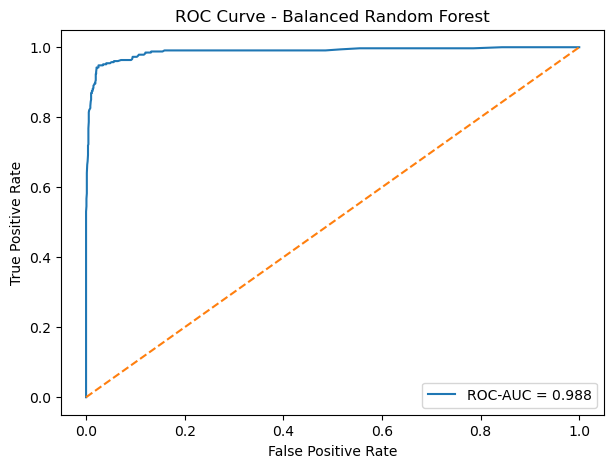

In [95]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt

# Probability of class 1
y_prob = brf_no_country_no_cat.predict_proba(
    X_test_reduced
)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# PR-AUC
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Balanced Random Forest")
plt.legend()
plt.show()

## ROC AND AUC CURVE for Decision Tree

In [125]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt

# Probability of class 1
y_prob = lr_model.(
    X_test_reduced
)[:, 1]

# ROC
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)

# PR-AUC
pr_auc = average_precision_score(
    y_test,
    y_prob
)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"ROC-AUC = {roc_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision tree")
plt.legend()
plt.show()

AttributeError: 'ModelBuilding' object has no attribute 'predict_proba'

### Model Comprasion

In [55]:
from sklearn.metrics import classification_report

In [45]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.ensemble import BalancedRandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        n_jobs=-1,
        random_state=42
    ),

    'Decision Tree': DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,max_depth=6
    ),

    'Balanced Random Forest': BalancedRandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

In [46]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

import pandas as pd


class Best_model_selection:

    def __init__(
        self,
        model,
        X_train,
        y_train,
        X_test=None,
        y_test=None
    ):

        self.models = model
        self.X_train = X_train
        self.y_train = y_train
        self.X_test = X_test
        self.y_test = y_test

    def Train_models(self):

        cv = StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        )

        results = []

        scoring = {
            'accuracy': 'accuracy',
            'precision': 'precision',
            'recall': 'recall',
            'f1': 'f1',
            'roc_auc': 'roc_auc',
            'pr_auc': 'average_precision'
        }

        for name, model in self.models.items():

            # -----------------------------
            # Cross Validation
            # -----------------------------

            cv_result = cross_validate(
                model,
                self.X_train,
                self.y_train,
                cv=cv,
                scoring=scoring,
                n_jobs=-1
            )

            # -----------------------------
            # Train model
            # -----------------------------

            model.fit(
                self.X_train,
                self.y_train
            )

            # -----------------------------
            # Test prediction
            # -----------------------------

            y_pred = model.predict(
                self.X_test
            )

            y_prob = model.predict_proba(
                self.X_test
            )[:, 1]

            # -----------------------------
            # Store results
            # -----------------------------

            results.append({

                'Model': name,

                # CV results
                'CV F1 Mean': cv_result['test_f1'].mean(),
                'CV F1 Std': cv_result['test_f1'].std(),

                'CV Precision Mean':
                    cv_result['test_precision'].mean(),

                'CV Recall Mean':
                    cv_result['test_recall'].mean(),

                'CV ROC-AUC Mean':
                    cv_result['test_roc_auc'].mean(),

                'CV PR-AUC Mean':
                    cv_result['test_pr_auc'].mean(),

                # Test results
                'Test Accuracy':
                    accuracy_score(self.y_test, y_pred),

                'Test Precision':
                    precision_score(
                        self.y_test,
                        y_pred,
                        zero_division=0
                    ),

                'Test Recall':
                    recall_score(
                        self.y_test,
                        y_pred,
                        zero_division=0
                    ),

                'Test F1':
                    f1_score(
                        self.y_test,
                        y_pred,
                        zero_division=0
                    ),

                'Test ROC-AUC':
                    roc_auc_score(
                        self.y_test,
                        y_prob
                    ),

                'Test PR-AUC':
                    average_precision_score(
                        self.y_test,
                        y_prob
                    )
            })

        # -----------------------------
        # Final DataFrame
        # -----------------------------

        self.results_df = pd.DataFrame(results)

        return self.results_df.T
        

In [47]:
m1 = Best_model_selection(model=models,
                          X_train=X_train_reduced,
                          y_train=y_train,
                          X_test=X_test_reduced,
                         y_test=y_test)
m1.Train_models()

NameError: name 'X_train_reduced' is not defined

In [130]:
len(X_train_reduced.columns)

30

## So from the above we can choose the BALANCED RANDOM FOREST AS THE MODEL 

## PERFROMING THE GRID SEARCH CV 

In [99]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

In [100]:
from sklearn.model_selection import GridSearchCV

In [101]:
grid_search = GridSearchCV(brf_no_country_no_cat,
             param_grid=param_grid,
             n_jobs=-1,
            verbose=1,
            scoring='f1')

grid_search.fit(X_train_reduced ,y_train)

grid_search.best_estimator_

print(classification_report(grid_search.predict(X_test_reduced),y_test))

## Grid_search_cv on Decision tree

In [132]:
param_grid = {
    'max_depth': [ 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10]
}

In [133]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)


grid_search_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(
    X_train_reduced,
    y_train
)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(cv=5,
             estimator=DecisionTreeClassifier(class_weight='balanced',
                                              random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [5, 6, 7, 8],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='f1', verbose=1)

In [134]:
grid_search_dt.best_estimator_

DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=2,
                       random_state=42)

In [135]:
print("Best CV F1:", grid_search_dt.best_score_)
print("Best Parameters:", grid_search_dt.best_params_)

Best CV F1: 0.8919957646145029
Best Parameters: {'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 2}


In [136]:
print(classification_report(y_pred=grid_search_dt.predict(X_test_reduced),y_true=y_test))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1271
           1       0.87      0.93      0.90       328

    accuracy                           0.96      1599
   macro avg       0.93      0.95      0.94      1599
weighted avg       0.96      0.96      0.96      1599



## Business Decision Framework

After selecting the Balanced Random Forest as the final churn prediction
model, the next step is to convert the model predictions into actionable
business decisions.

The model predicts the probability that each customer will churn. However,
churn probability alone does not indicate how valuable a customer is to the
business.

Therefore, the model predictions will be combined with the previously
created RFM (Recency, Frequency, Monetary) customer segmentation.

### Objective

The objective is to identify:

1. Customers who are highly likely to churn.
2. Customers who are financially valuable to the business.
3. Customers who require immediate retention actions.
4. Customers who require lower-cost or automated retention campaigns.
5. Customers who have a low churn risk and therefore require less immediate
   intervention.

### Approach

The Balanced Random Forest will provide a churn probability for every
customer.

The RFM analysis will provide information about the customer's:

- Recency – how recently the customer purchased.
- Frequency – how frequently the customer purchases.
- Monetary – how much the customer spends.

These two sources of information will then be combined to create customer
priority segments.

### Business Decision

Customers with both high churn probability and high customer value will be
given the highest priority for retention.

Customers with high churn probability but low customer value can be targeted
using lower-cost or automated campaigns.

Customers with low churn probability will generally require less immediate
retention intervention.

This approach allows the business to move from simply predicting churn to
deciding which customers should be targeted, why they should be targeted,
and what type of retention action should be considered.

In [102]:
len(X_train_reduced.columns)

30

In [103]:
X_train_reduced.columns

Index(['log__total_orders', 'log__total_spend_usd', 'log__avg_order_value_usd',
       'log__days_since_last_purchase', 'log__reviews_given',
       'log__returns_made', 'log__wishlist_items', 'onehot__gender_Female',
       'onehot__gender_Male', 'onehot__gender_Other',
       'onehot__preferred_device_Desktop', 'onehot__preferred_device_Mobile',
       'onehot__preferred_device_Tablet',
       'onehot__preferred_payment_method_Bank Transfer',
       'onehot__preferred_payment_method_Buy Now Pay Later',
       'onehot__preferred_payment_method_Credit Card',
       'onehot__preferred_payment_method_Cryptocurrency',
       'onehot__preferred_payment_method_Debit Card',
       'onehot__preferred_payment_method_PayPal',
       'onehot__preferred_payment_method_UPI / Digital Wallet',
       'onehot__acquisition_channel_Direct',
       'onehot__acquisition_channel_Email Campaign',
       'onehot__acquisition_channel_Organic Search',
       'onehot__acquisition_channel_Paid Ad',
       'oneh

## Final MOdel Training Labels

In [48]:
log_cols = [
    'total_orders',
    'total_spend_usd',
    'avg_order_value_usd',
    'days_since_last_purchase',
    'reviews_given',
    'returns_made',
    'wishlist_items'
]

onehot_cols = [
    'gender',
    'preferred_device',
    'preferred_payment_method',
    'acquisition_channel'
]

ordinal_cols = [
    'membership_tier'
]

numeric_cols = [
    'age',
    'avg_review_score',
    'newsletter_subscribed'
]

## Transformations

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, OrdinalEncoder
import numpy as np

t1 = Pipeline([
    ('log_1p',
     FunctionTransformer(
         np.log1p,
         feature_names_out='one-to-one'
     ))
])


t2 = Pipeline([
    ('one-hot-encoding',
     OneHotEncoder(
         handle_unknown='ignore',
         sparse_output=False
     ))
])


t3 = Pipeline([
    ('Ordinal-encoding',
     OrdinalEncoder(
         categories=[['Free', 'Silver', 'Gold', 'Platinum']]
     ))
])

### Final preprocessor

In [50]:
model_preprocessor = ColumnTransformer(
    transformers=[
    ('log', t1, log_cols),
    
    ('onehot', t2, onehot_cols),
    
    ('ordinal', t3, ordinal_cols),
    
    ('numeric', 'passthrough', numeric_cols)],
    remainder='drop'
)

## final Balanced Random forest Model

In [51]:
brf_final = BalancedRandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

## Final_pipline

In [52]:
Brf_final_pipeline = Pipeline([
    ('preprocessor', model_preprocessor),
    ('model', brf_final)
])

In [53]:
Brf_final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [56]:
print(classification_report(y_pred=Brf_final_pipeline.predict(X_test),y_true=y_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1271
           1       0.90      0.89      0.90       329

    accuracy                           0.96      1600
   macro avg       0.94      0.93      0.93      1600
weighted avg       0.96      0.96      0.96      1600



## final Decision tree Model

In [57]:
decision_tree = DecisionTreeClassifier(
        class_weight='balanced',
        random_state=42,max_depth=6)

Decision_tree_final_pipeline = Pipeline([
    ('preprocessor', model_preprocessor),
    ('model', decision_tree)
])

In [58]:
Decision_tree_final_pipeline.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('log', ...), ('onehot', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [59]:
print(classification_report(y_pred=Decision_tree_final_pipeline.predict(X_test),y_true=y_test))

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1271
           1       0.89      0.88      0.89       329

    accuracy                           0.95      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.95      0.95      0.95      1600



## Final Pipline 

In [112]:
rfm_customer  = df.merge(rfm,how='inner',on='customer_id')[['customer_id','days_since_last_purchase_R',
                                            'total_orders_F','total_spend_usd_M','R_score',
                                           'F_score','M_score']]

In [113]:
rfm_customer.head(10)

,customer_id,days_since_last_purchase_R,total_orders_F,total_spend_usd_M,R_score,F_score,M_score
0,C00001,49,4,286.63,3,1,4
1,C00002,107,11,1245.18,5,2,2
2,C00003,0,24,195.37,1,4,5
3,C00004,6,6,99.45,1,1,5
4,C00005,48,13,2593.21,3,2,1
5,C00006,4,20,1639.15,1,3,2
6,C00007,51,27,200.79,3,4,5
7,C00008,122,17,947.14,5,3,3
8,C00009,4,18,4320.40,1,3,1
9,C00010,82,17,111.38,4,3,5


In [114]:
predictions = X_test.copy()

predictions['churn_prediction'] = y_pred
predictions['churn_probability'] = y_prob

## Lets connect the Predictions and the bring insights  to the Business 

In [115]:
business_df = rfm_customer.merge(predictions,
                  on='customer_id',
                  how='inner')[['customer_id'
                                ,'R_score',
                                'F_score',
                              'M_score',
                              'churn_probability' ]]

In [116]:
business_df.sample(5)

,customer_id,R_score,F_score,M_score,churn_probability
957,C04786,1,4,2,0.070
1145,C05798,2,4,2,0.020
1302,C06587,1,2,2,0.050
1489,C07429,4,4,4,0.035
1122,C05669,1,3,5,0.005


## RFM Score is the Combination of the R_score	F_score	M_score to get the insights more effectively 

In [117]:
business_df['RFM_score'] = business_df['R_score'] + business_df['F_score'] + business_df['M_score'] 

In [118]:
business_df.sample(5)

,customer_id,R_score,F_score,M_score,churn_probability,RFM_score
1137,C05744,5,1,1,0.945,7
739,C03783,2,2,4,0.055,8
949,C04753,2,1,3,0.355,6
40,C00252,3,4,2,0.010,9
1236,C06245,3,1,5,0.395,9


## Customers to focus on immediately 🔴

In [119]:
business_df[
    (business_df['churn_probability'] >= 0.70) &
    (business_df['RFM_score'] >= 12)
].sort_values('churn_probability', ascending=False)

,customer_id,R_score,F_score,M_score,churn_probability,RFM_score
283,C01502,5,2,5,0.970,12
140,C00831,5,2,5,0.960,12
179,C01018,5,2,5,0.960,12
768,C03924,5,2,5,0.955,12
448,C02392,5,2,5,0.945,12
248,C01333,5,5,3,0.945,13
90,C00567,5,4,3,0.940,12
1067,C05360,5,2,5,0.935,12
1491,C07433,5,2,5,0.935,12
286,C01528,5,3,4,0.920,12


These are:

#### High churn probability + High RFM value

### They are valuable customers and likely to churn.

## Business action: personalized retention, priority outreach, strong but controlled incentive.

### Customers who need more attention 🟠

## These are customers who are either:

## high churn probability but medium RFM value, or
## moderate churn probability but high RFM value.

In [120]:
business_df[
    (
        (business_df['churn_probability'] >= 0.70) &
        (business_df['RFM_score'].between(7, 11))
    )
    |
    (
        (business_df['churn_probability'].between(0.30, 0.69)) &
        (business_df['RFM_score'] >= 12)
    )
].sort_values(
    'churn_probability',
    ascending=False
)

,customer_id,R_score,F_score,M_score,churn_probability,RFM_score
368,C02044,5,1,5,1.000,11
1166,C05909,5,1,4,1.000,10
100,C00614,5,1,5,1.000,11
1537,C07661,5,1,4,0.995,10
1326,C06674,5,1,2,0.995,8
...,...,...,...,...,...,...
1013,C05145,5,5,3,0.310,13
1357,C06820,5,5,4,0.300,14
434,C02343,5,5,2,0.300,12
73,C00446,5,3,5,0.300,13


### Business action: targeted campaigns, personalized recommendations, monitor their behaviour.

## Customers most likely to churn 🔴

Customers with the highest predicted probability of churn.

In [121]:
business_df[
    (business_df['churn_probability'] >= 0.90) & (business_df['RFM_score'] <=5)
].sort_values(
    'churn_probability',
    ascending=False
)

,customer_id,R_score,F_score,M_score,churn_probability,RFM_score
1342,C06739,1,1,3,0.940,5
423,C02313,1,1,3,0.935,5
324,C01746,1,2,1,0.900,4


### Business action: investigate why they are leaving and determine whether retention is economically worthwhile.

## Business Decision Framework

| **Business Question** | **Definition** | **Business Action** |
|---|---|---|
| 🟢 **Which customers should we focus on immediately?** | High churn probability + High RFM value | Priority retention |
| 🟠 **Which customers need more attention?** | Medium/High churn probability + Medium/High RFM value | Targeted intervention |
| 🔴 **Which customers are most likely to churn?** | Churn probability ≥ 90% | Immediate investigation / retention decision |

## This can actually change according to the Business Decisions 

### Save the model metrics and Parameters in MLflow

In [61]:
import mlflow

c:\Users\sam\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [62]:
final_modlels = {
    
    'Decision_tree':{
        'model':Decision_tree_final_pipeline,
        'params':Decision_tree_final_pipeline.named_steps['model'].get_params()
    },
    
    "Balanced_Random_forest":{
        
        'model': Brf_final_pipeline,
        'params':Brf_final_pipeline.named_steps['model'].get_params()
    }
}

In [63]:
reports = []

for model_name , model_info  in final_modlels.items():
    
    model = model_info['model']
    params = model_info['params']
    
    y_pred = model.predict(X_test)
    
    report = classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
    
    reports.append(report)
    

In [65]:
mlflow.set_experiment("Churn_prediction_experiments")
mlflow.set_tracking_uri("http://localhost:5000")

trusted_types = [
    "imblearn.ensemble._forest.BalancedRandomForestClassifier",
    "imblearn.pipeline.Pipeline",
    "imblearn.under_sampling._prototype_selection._random_under_sampler.RandomUnderSampler"
]

for index, (model_name, model_info) in enumerate(final_modlels.items()):
    
    model = model_info['model']
    params = model_info['params']
    
    with mlflow.start_run(run_name=model_name):
        
        mlflow.log_params(params)
        
        mlflow.log_metrics({
            "class_0_precision": reports[index]["0"]["precision"],
            "class_0_recall": reports[index]["0"]["recall"],
            "class_0_f1-score": reports[index]["0"]["f1-score"],
            
            "class_1_precision": reports[index]["1"]["precision"],
            "class_1_recall": reports[index]["1"]["recall"],
            "class_1_f1-score": reports[index]["1"]["f1-score"]
        })
        
        mlflow.sklearn.log_model(
            model,
            name=model_name,
            skops_trusted_types=trusted_types
        )

🏃 View run Decision_tree at: http://localhost:5000/#/experiments/1/runs/203bd90ad10b4f288c57a76bf56dda2b
🧪 View experiment at: http://localhost:5000/#/experiments/1
🏃 View run Balanced_Random_forest at: http://localhost:5000/#/experiments/1/runs/fe39cdc18d48434ebff2917741c64833
🧪 View experiment at: http://localhost:5000/#/experiments/1


## Model Regsistry

### Balanced RandomForest is Registered as The champion 

In [68]:
model_name = 'Balanced_Random_forest'
run_id = 'fe39cdc18d48434ebff2917741c64833'
model_uri = f'runs:/{run_id}/{model_name}'

In [69]:
with mlflow.start_run(run_id=run_id):
    mlflow.register_model(model_uri=model_uri,name=model_name)

Successfully registered model 'Balanced_Random_forest'.
2026/09/03 17:45:08 WARNING mlflow.tracking._model_registry.fluent: Run with id fe39cdc18d48434ebff2917741c64833 has no artifacts at artifact path 'Balanced_Random_forest', registering model based on models:/m-162b318b67fa4f24b0fa61596f155f41 instead
2026/09/03 17:45:08 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Balanced_Random_forest, version 1


🏃 View run Balanced_Random_forest at: http://localhost:5000/#/experiments/1/runs/fe39cdc18d48434ebff2917741c64833
🧪 View experiment at: http://localhost:5000/#/experiments/1


Created version '1' of model 'Balanced_Random_forest'.


## Model Regsistry

### Decision Tree is Registerd as The Challenger 

In [1]:
import mlflow

In [70]:
model_name = 'Decision_tree'
run_id='203bd90ad10b4f288c57a76bf56dda2b'
model_uri = f'runs:/{run_id}/{model_name}'

with mlflow.start_run(run_id=run_id):
    mlflow.register_model(model_uri=model_uri, name=model_name)

Successfully registered model 'Decision_tree'.
2026/09/03 17:45:49 WARNING mlflow.tracking._model_registry.fluent: Run with id 203bd90ad10b4f288c57a76bf56dda2b has no artifacts at artifact path 'Decision_tree', registering model based on models:/m-2d5babffc99643939e460561bea953a2 instead
2026/09/03 17:45:49 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: Decision_tree, version 1


🏃 View run Decision_tree at: http://localhost:5000/#/experiments/1/runs/203bd90ad10b4f288c57a76bf56dda2b
🧪 View experiment at: http://localhost:5000/#/experiments/1


Created version '1' of model 'Decision_tree'.


In [72]:
production_model_name = 'Balanced_Random_forest'
model_uri = f"models:/{production_model_name}@champion"

loaded_model = mlflow.sklearn.load_model(model_uri)
y_pred = loaded_model.predict(X_test)
y_pred[:4]

array([0, 0, 1, 0])

In [1]:
import mlflow

In [2]:
production_model_name = 'Balanced_Random_forest'
model_uri = f"models:/{production_model_name}@champion"


In [76]:
X_train

,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed
5170,United States,58,Female,Free,20,4652.03,232.60,36,Sports & Outdoors,Mobile,PayPal,Paid Ad,3,4.1,2,7,0
5742,Spain,28,Male,Silver,9,1291.73,143.53,205,Electronics,Mobile,Bank Transfer,Direct,8,4.0,2,5,1
3282,India,41,Male,Gold,1,2883.62,2883.62,74,Beauty & Personal Care,Mobile,Credit Card,Social Media,5,4.7,1,5,1
2648,Poland,29,Male,Free,8,161.10,20.14,12,Clothing & Apparel,Desktop,PayPal,Social Media,0,3.4,0,3,0
1970,United States,50,Female,Free,5,577.30,115.46,41,Beauty & Personal Care,Desktop,PayPal,Social Media,1,4.5,0,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107,Canada,40,Male,Silver,21,373.47,17.78,35,Health & Wellness,Desktop,Debit Card,Organic Search,0,3.9,2,8,1
7248,United States,31,Female,Gold,11,439.72,39.97,54,Electronics,Mobile,Credit Card,Organic Search,3,4.1,0,3,1
4288,United Kingdom,32,Male,Platinum,17,1372.97,80.76,77,Health & Wellness,Mobile,UPI / Digital Wallet,Social Media,6,3.8,2,5,1
7494,Canada,39,Female,Free,25,1105.21,44.21,3,Sports & Outdoors,Mobile,Debit Card,Social Media,7,4.4,1,0,1


In [74]:
len(X_train.columns)

17

In [75]:
X_test

,country,age,gender,membership_tier,total_orders,total_spend_usd,avg_order_value_usd,days_since_last_purchase,preferred_category,preferred_device,preferred_payment_method,acquisition_channel,reviews_given,avg_review_score,returns_made,wishlist_items,newsletter_subscribed
6845,United Kingdom,48,Male,Platinum,34,3799.12,111.74,50,Sports & Outdoors,Mobile,UPI / Digital Wallet,Email Campaign,6,4.700000,1,3,1
4100,United States,41,Male,Free,15,512.65,34.18,27,Clothing & Apparel,Tablet,UPI / Digital Wallet,Paid Ad,3,5.000000,0,6,1
6122,South Korea,25,Male,Gold,35,3753.37,107.24,163,Electronics,Mobile,UPI / Digital Wallet,Paid Ad,3,2.009805,2,2,0
6980,Netherlands,43,Male,Free,29,371.61,12.81,68,Electronics,Mobile,PayPal,Social Media,1,3.700000,0,0,1
4413,United States,65,Male,Free,8,250.68,31.34,61,Electronics,Desktop,PayPal,Organic Search,2,4.900000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,United Kingdom,26,Female,Free,13,3119.76,239.98,13,Toys & Games,Mobile,Cryptocurrency,Social Media,13,2.600000,2,5,0
2368,United States,24,Male,Silver,17,569.34,33.49,12,Electronics,Desktop,PayPal,Organic Search,3,4.200000,0,4,1
2088,France,27,Male,Free,26,3217.20,123.74,59,Electronics,Mobile,Credit Card,Social Media,7,4.300000,0,5,1
4441,UAE,56,Male,Free,14,7175.41,512.53,2,Sports & Outdoors,Desktop,Bank Transfer,Organic Search,6,3.900000,0,14,1


In [ ]:
{
  "country": "Canada",
  "age": 28,
  "gender": "Male",
  "membership_tier": "Gold",
  "total_orders": 12,
  "total_spend_usd": 850.50,
  "avg_order_value_usd": 70.88,
  "days_since_last_purchase": 25,
  "preferred_category": "Electronics",
  "preferred_device": "Mobile",
  "preferred_payment_method": "Credit Card",
  "acquisition_channel": "Social Media",
  "reviews_given": 8,
  "avg_review_score": 4.2,
  "returns_made": 1,
  "wishlist_items": 5,
  "newsletter_subscribed": 1
}